<a href="https://colab.research.google.com/github/bioinformaticswoman/RNA-seq-analysis/blob/main/DEA_with_DESeq2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [165]:
!pip install -q rpy2

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [166]:
%%R

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager")
}

bioc_packages <- c(
  "DESeq2",
  "GEOquery",
  "SummarizedExperiment",
  "apeglm",
  "EnhancedVolcano",
  "pheatmap"
)

cran_packages <- c(
  "ggplot2",
  "dplyr",
  "readr",
  "tibble"
)

for (pkg in cran_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
}

for (pkg in bioc_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    BiocManager::install(pkg, ask = FALSE, update = FALSE)
  }
}


In [167]:
%%R

library(DESeq2)
library(GEOquery)
library(SummarizedExperiment)
library(apeglm)
library(EnhancedVolcano)
library(pheatmap)
library(ggplot2)
library(dplyr)
library(readr)
library(tibble)


In [168]:
%%R

geo_accession <- "GSE164073"

se <- getRNASeqData(geo_accession)

se


class: SummarizedExperiment 
dim: 39376 18 
metadata(5): experimentData annotation protocolData genomeInfo
  created_at
assays(1): counts
rownames(39376): 100287102 653635 ... 4576 4571
rowData names(18): GeneID Symbol ... GOProcess GOComponent
colnames(18): GSM4996084 GSM4996085 ... GSM4996100 GSM4996101
colData names(45): title geo_accession ... time.point.ch1 tissue.ch1


 [100%] Downloaded 787241 bytes...
 [100%] Downloaded 4417321 bytes...
Found 1 file(s)
GSE164073_series_matrix.txt.gz
Using locally cached version: /tmp/RtmppQGtH9/GSE164073_series_matrix.txt.gz
Using locally cached version of GPL18573 found here:
/tmp/RtmppQGtH9/GPL18573.soft.gz 


In [169]:
%%R

dim(assay(se, "counts"))

colnames(se)

colnames(colData(se))

as.data.frame(colData(se))[, c("geo_accession", "title")]


           geo_accession         title
GSM4996084    GSM4996084 Cornea_mock_1
GSM4996085    GSM4996085 Cornea_mock_2
GSM4996086    GSM4996086 Cornea_mock_3
GSM4996087    GSM4996087 Cornea_CoV2_1
GSM4996088    GSM4996088 Cornea_CoV2_2
GSM4996089    GSM4996089 Cornea_CoV2_3
GSM4996090    GSM4996090 Limbus_mock_1
GSM4996091    GSM4996091 Limbus_mock_2
GSM4996092    GSM4996092 Limbus_mock_3
GSM4996093    GSM4996093 Limbus_CoV2_1
GSM4996094    GSM4996094 Limbus_CoV2_2
GSM4996095    GSM4996095 Limbus_CoV2_3
GSM4996096    GSM4996096 Sclera_mock_1
GSM4996097    GSM4996097 Sclera_mock_2
GSM4996098    GSM4996098 Sclera_mock_3
GSM4996099    GSM4996099 Sclera_CoV2_1
GSM4996100    GSM4996100 Sclera_CoV2_2
GSM4996101    GSM4996101 Sclera_CoV2_3


In [170]:
%%R

sample_info <- as.data.frame(colData(se))

sample_info <- sample_info %>%
  mutate(
    tissue = case_when(
      grepl("Cornea", title, ignore.case = TRUE) ~ "cornea",
      grepl("Limbus", title, ignore.case = TRUE) ~ "limbus",
      grepl("Sclera", title, ignore.case = TRUE) ~ "sclera",
      TRUE ~ NA_character_
    ),
    condition = case_when(
      grepl("mock", title, ignore.case = TRUE) ~ "mock",
      grepl("CoV2", title, ignore.case = TRUE) ~ "SARS_CoV_2",
      TRUE ~ NA_character_
    )
  )

sample_info[, c("geo_accession", "title", "tissue", "condition")]


           geo_accession         title tissue  condition
GSM4996084    GSM4996084 Cornea_mock_1 cornea       mock
GSM4996085    GSM4996085 Cornea_mock_2 cornea       mock
GSM4996086    GSM4996086 Cornea_mock_3 cornea       mock
GSM4996087    GSM4996087 Cornea_CoV2_1 cornea SARS_CoV_2
GSM4996088    GSM4996088 Cornea_CoV2_2 cornea SARS_CoV_2
GSM4996089    GSM4996089 Cornea_CoV2_3 cornea SARS_CoV_2
GSM4996090    GSM4996090 Limbus_mock_1 limbus       mock
GSM4996091    GSM4996091 Limbus_mock_2 limbus       mock
GSM4996092    GSM4996092 Limbus_mock_3 limbus       mock
GSM4996093    GSM4996093 Limbus_CoV2_1 limbus SARS_CoV_2
GSM4996094    GSM4996094 Limbus_CoV2_2 limbus SARS_CoV_2
GSM4996095    GSM4996095 Limbus_CoV2_3 limbus SARS_CoV_2
GSM4996096    GSM4996096 Sclera_mock_1 sclera       mock
GSM4996097    GSM4996097 Sclera_mock_2 sclera       mock
GSM4996098    GSM4996098 Sclera_mock_3 sclera       mock
GSM4996099    GSM4996099 Sclera_CoV2_1 sclera SARS_CoV_2
GSM4996100    GSM4996100 Sclera

In [171]:
%%R

cornea_samples <- sample_info %>%
  filter(tissue == "cornea") %>%
  pull(geo_accession)

cornea_samples


[1] "GSM4996084" "GSM4996085" "GSM4996086" "GSM4996087" "GSM4996088"
[6] "GSM4996089"


In [172]:
%%R

count_data <- assay(se, "counts")[, cornea_samples]

metadata <- sample_info %>%
  filter(geo_accession %in% cornea_samples) %>%
  select(geo_accession, title, tissue, condition)

rownames(metadata) <- metadata$geo_accession

metadata <- metadata[colnames(count_data), ]

metadata$condition <- factor(metadata$condition)

all(colnames(count_data) == rownames(metadata))

metadata


           geo_accession         title tissue  condition
GSM4996084    GSM4996084 Cornea_mock_1 cornea       mock
GSM4996085    GSM4996085 Cornea_mock_2 cornea       mock
GSM4996086    GSM4996086 Cornea_mock_3 cornea       mock
GSM4996087    GSM4996087 Cornea_CoV2_1 cornea SARS_CoV_2
GSM4996088    GSM4996088 Cornea_CoV2_2 cornea SARS_CoV_2
GSM4996089    GSM4996089 Cornea_CoV2_3 cornea SARS_CoV_2


In [173]:
%%R

dds <- DESeqDataSetFromMatrix(
  countData = count_data,
  colData = metadata,
  design = ~ condition
)

dds


class: DESeqDataSet 
dim: 39376 6 
metadata(1): version
assays(1): counts
rownames(39376): 100287102 653635 ... 4576 4571
rowData names(0):
colnames(6): GSM4996084 GSM4996085 ... GSM4996088 GSM4996089
colData names(4): geo_accession title tissue condition


converting counts to integer mode


In [174]:
%%R

keep <- rowSums(counts(dds)) >= 10

dds <- dds[keep, ]

dds


class: DESeqDataSet 
dim: 20844 6 
metadata(1): version
assays(1): counts
rownames(20844): 100287102 653635 ... 4576 4571
rowData names(0):
colnames(6): GSM4996084 GSM4996085 ... GSM4996088 GSM4996089
colData names(4): geo_accession title tissue condition


In [175]:
%%R

dds$condition <- relevel(dds$condition, ref = "mock")

levels(dds$condition)


[1] "mock"       "SARS_CoV_2"


In [176]:
%%R

dds <- DESeq(dds)


estimating size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing


In [177]:
%%R

resultsNames(dds)


[1] "Intercept"                    "condition_SARS_CoV_2_vs_mock"


In [178]:
%%R

res <- results(
  dds,
  contrast = c("condition", "SARS_CoV_2", "mock")
)

res_ordered <- res[order(res$padj), ]

head(res_ordered)


log2 fold change (MLE): condition SARS_CoV_2 vs mock 
Wald test p-value: condition SARS CoV 2 vs mock 
DataFrame with 6 rows and 6 columns
       baseMean log2FoldChange     lfcSE      stat       pvalue         padj
      <numeric>      <numeric> <numeric> <numeric>    <numeric>    <numeric>
6648  17052.785        2.99550  0.108691   27.5599 3.37206e-167 4.98458e-163
718    4294.524        2.05089  0.104153   19.6910  2.57510e-86  1.90325e-82
64116   593.963        2.22278  0.126756   17.5359  7.62733e-69  3.75824e-65
629     457.796        2.52656  0.160755   15.7168  1.15997e-55  4.28668e-52
7128    464.891        1.99291  0.137020   14.5447  6.31016e-48  1.86554e-44
9052    545.236       -1.83410  0.141467  -12.9649  1.93591e-38  4.76943e-35


In [179]:
%%R

summary(res)



out of 20844 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 564, 2.7%
LFC < 0 (down)     : 801, 3.8%
outliers [1]       : 0, 0%
low counts [2]     : 6062, 29%
(mean count < 21)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [180]:
%%R

res_df <- as.data.frame(res_ordered) %>%
  rownames_to_column(var = "GeneID") %>%
  filter(!is.na(padj))

head(res_df)


  GeneID   baseMean log2FoldChange     lfcSE      stat        pvalue
1   6648 17052.7854       2.995498 0.1086906  27.55985 3.372060e-167
2    718  4294.5236       2.050885 0.1041534  19.69101  2.575096e-86
3  64116   593.9631       2.222776 0.1267560  17.53587  7.627332e-69
4    629   457.7959       2.526555 0.1607548  15.71682  1.159974e-55
5   7128   464.8912       1.992914 0.1370199  14.54471  6.310162e-48
6   9052   545.2357      -1.834097 0.1414668 -12.96486  1.935906e-38
           padj
1 4.984579e-163
2  1.903253e-82
3  3.758241e-65
4  4.286683e-52
5  1.865536e-44
6  4.769428e-35


In [181]:
%%R

# Convert gene annotation to a regular data frame
gene_annotation_raw <- as.data.frame(rowData(se))

# Check the available annotation columns
colnames(gene_annotation_raw)



 [1] "GeneID"        "Symbol"        "Description"   "Synonyms"     
 [5] "GeneType"      "EnsemblGeneID" "Status"        "ChrAcc"       
 [9] "ChrStart"      "ChrStop"       "Orientation"   "Length"       
[13] "GOFunctionID"  "GOProcessID"   "GOComponentID" "GOFunction"   
[17] "GOProcess"     "GOComponent"  


In [182]:
%%R

gene_annotation_raw <- as.data.frame(rowData(se))

# Make sure GeneID is character, so it joins cleanly with res_df
gene_annotation_raw$GeneID <- as.character(gene_annotation_raw$GeneID)
res_df$GeneID <- as.character(res_df$GeneID)

# If Symbol exists, use it. Otherwise use GeneID as a fallback.
if ("Symbol" %in% colnames(gene_annotation_raw)) {
  gene_annotation_raw$Symbol_clean <- gene_annotation_raw$Symbol
} else {
  gene_annotation_raw$Symbol_clean <- gene_annotation_raw$GeneID
}

# If Description exists, use it. Otherwise fill with NA.
if ("Description" %in% colnames(gene_annotation_raw)) {
  gene_annotation_raw$Description_clean <- gene_annotation_raw$Description
} else {
  gene_annotation_raw$Description_clean <- NA_character_
}

gene_annotation <- gene_annotation_raw %>%
  dplyr::select(
    GeneID,
    Symbol = Symbol_clean,
    Description = Description_clean
  ) %>%
  dplyr::distinct(GeneID, .keep_all = TRUE)

res_annotated <- res_df %>%
  dplyr::left_join(gene_annotation, by = "GeneID") %>%
  dplyr::relocate(Symbol, Description, .after = GeneID)

head(res_annotated)


  GeneID  Symbol                                         Description   baseMean
1   6648    SOD2                              superoxide dismutase 2 17052.7854
2    718      C3                                       complement C3  4294.5236
3  64116 SLC39A8                   solute carrier family 39 member 8   593.9631
4    629     CFB                                 complement factor B   457.7959
5   7128 TNFAIP3                         TNF alpha induced protein 3   464.8912
6   9052  GPRC5A G protein-coupled receptor class C group 5 member A   545.2357
  log2FoldChange     lfcSE      stat        pvalue          padj
1       2.995498 0.1086906  27.55985 3.372060e-167 4.984579e-163
2       2.050885 0.1041534  19.69101  2.575096e-86  1.903253e-82
3       2.222776 0.1267560  17.53587  7.627332e-69  3.758241e-65
4       2.526555 0.1607548  15.71682  1.159974e-55  4.286683e-52
5       1.992914 0.1370199  14.54471  6.310162e-48  1.865536e-44
6      -1.834097 0.1414668 -12.96486  1.935906e-38

In [183]:
%%R

significant_genes <- res_annotated %>%
  filter(padj < 0.05, abs(log2FoldChange) >= 1)

upregulated_genes <- significant_genes %>%
  filter(log2FoldChange > 0)

downregulated_genes <- significant_genes %>%
  filter(log2FoldChange < 0)

cat("Significant genes:", nrow(significant_genes), "\n")
cat("Upregulated genes:", nrow(upregulated_genes), "\n")
cat("Downregulated genes:", nrow(downregulated_genes), "\n")

head(significant_genes)


Significant genes: 122 
Upregulated genes: 55 
Downregulated genes: 67 
  GeneID  Symbol                                         Description   baseMean
1   6648    SOD2                              superoxide dismutase 2 17052.7854
2    718      C3                                       complement C3  4294.5236
3  64116 SLC39A8                   solute carrier family 39 member 8   593.9631
4    629     CFB                                 complement factor B   457.7959
5   7128 TNFAIP3                         TNF alpha induced protein 3   464.8912
6   9052  GPRC5A G protein-coupled receptor class C group 5 member A   545.2357
  log2FoldChange     lfcSE      stat        pvalue          padj
1       2.995498 0.1086906  27.55985 3.372060e-167 4.984579e-163
2       2.050885 0.1041534  19.69101  2.575096e-86  1.903253e-82
3       2.222776 0.1267560  17.53587  7.627332e-69  3.758241e-65
4       2.526555 0.1607548  15.71682  1.159974e-55  4.286683e-52
5       1.992914 0.1370199  14.54471  6.310

In [184]:
%%R

dir.create("results", showWarnings = FALSE)

write_csv(res_annotated, "results/DESeq2_all_results.csv")
write_csv(significant_genes, "results/DESeq2_significant_genes.csv")
write_csv(upregulated_genes, "results/DESeq2_upregulated_genes.csv")
write_csv(downregulated_genes, "results/DESeq2_downregulated_genes.csv")


In [185]:
%%R

dir.create("plots", showWarnings = FALSE)

png("plots/MA_plot.png", width = 900, height = 700)

plotMA(
  res,
  ylim = c(-8, 8),
  main = "MA Plot: SARS-CoV-2 vs Mock in Cornea"
)

dev.off()


png 
  2 


In [186]:
%%R

resultsNames(dds)

res_shrunken <- lfcShrink(
  dds,
  coef = "condition_SARS_CoV_2_vs_mock",
  type = "apeglm"
)

res_shrunken_df <- as.data.frame(res_shrunken) %>%
  rownames_to_column(var = "GeneID") %>%
  filter(!is.na(padj)) %>%
  left_join(gene_annotation, by = "GeneID") %>%
  relocate(Symbol, Description, .after = GeneID)

head(res_shrunken_df)


     GeneID       Symbol                              Description  baseMean
1    653635       WASH7P        WASP family homolog 7, pseudogene 269.25184
2 102466751    MIR6859-1                          microRNA 6859-1  23.38216
3 100996442 LOC100996442        WAS protein family homolog 2-like  44.40117
4    729737    LOC729737                uncharacterized LOC729737  75.30304
5 102723897       WASH9P WAS protein family homolog 9, pseudogene 238.32371
6 100132287 LOC100132287             uncharacterized LOC100132287 143.45220
  log2FoldChange     lfcSE    pvalue      padj
1     0.04206957 0.1185999 0.5575683 0.8419629
2    -0.01164679 0.1362726 0.7985330 0.9360242
3     0.01494975 0.1323531 0.7847104 0.9311740
4     0.03831772 0.1410066 0.4410232 0.7808366
5     0.03594269 0.1165362 0.6159315 0.8703614
6     0.05949116 0.1473780 0.2937667 0.6724009


using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895


In [187]:
%%R

# Make sure the plots folder exists
dir.create("plots", showWarnings = FALSE)

# Remove old volcano plot if it exists
if (file.exists("plots/volcano_plot.png")) {
  file.remove("plots/volcano_plot.png")
}

# Make sure gene labels are clean
res_shrunken_df$plot_label <- ifelse(
  is.na(res_shrunken_df$Symbol) | res_shrunken_df$Symbol == "",
  res_shrunken_df$GeneID,
  res_shrunken_df$Symbol
)

# Build the volcano plot as an object first
volcano_plot <- EnhancedVolcano(
  res_shrunken_df,
  lab = res_shrunken_df$plot_label,
  x = "log2FoldChange",
  y = "padj",
  title = "SARS-CoV-2 vs Mock in Cornea",
  subtitle = "DESeq2 differential expression",
  xlab = "Log2 fold change",
  ylab = "-log10 adjusted p-value",
  pCutoff = 0.05,
  FCcutoff = 1,
  pointSize = 2,
  labSize = 3,
  drawConnectors = TRUE,
  widthConnectors = 0.5
)

# Save using ggsave, which is more reliable in Colab
ggplot2::ggsave(
  filename = "plots/volcano_plot.png",
  plot = volcano_plot,
  width = 8,
  height = 7,
  dpi = 300
)

# Confirm file was created
file.exists("plots/volcano_plot.png")



[1] TRUE


In [188]:
%%R

vsd <- vst(dds, blind = FALSE)

pca_plot <- plotPCA(vsd, intgroup = "condition") +
  ggtitle("PCA Plot: Cornea RNA-seq Samples")

ggsave(
  filename = "plots/PCA_plot.png",
  plot = pca_plot,
  width = 7,
  height = 5,
  dpi = 300
)


using ntop=500 top features by variance


In [189]:
%%R

dir.create("plots", showWarnings = FALSE)

# Recreate vst object if needed
if (!exists("vsd")) {
  vsd <- vst(dds, blind = FALSE)
}

# Pick top 30 genes by adjusted p-value
top_genes <- res_shrunken_df %>%
  dplyr::filter(!is.na(padj)) %>%
  dplyr::arrange(padj) %>%
  dplyr::slice(1:30) %>%
  dplyr::pull(GeneID)

# Extract transformed expression values
top_gene_matrix <- assay(vsd)[top_genes, ]

# Scale each gene across samples
top_gene_matrix_scaled <- t(scale(t(top_gene_matrix)))

# Add sample annotation
annotation_col <- as.data.frame(colData(dds)[, "condition", drop = FALSE])

# Save heatmap directly to PNG
pheatmap::pheatmap(
  top_gene_matrix_scaled,
  annotation_col = annotation_col,
  show_rownames = TRUE,
  show_colnames = TRUE,
  main = "Top 30 Differentially Expressed Genes",
  filename = "plots/top_30_gene_heatmap.png",
  width = 8,
  height = 9
)

# Check whether file was saved
file.exists("plots/top_30_gene_heatmap.png")


[1] TRUE


Exists: True
Size: 169411 bytes


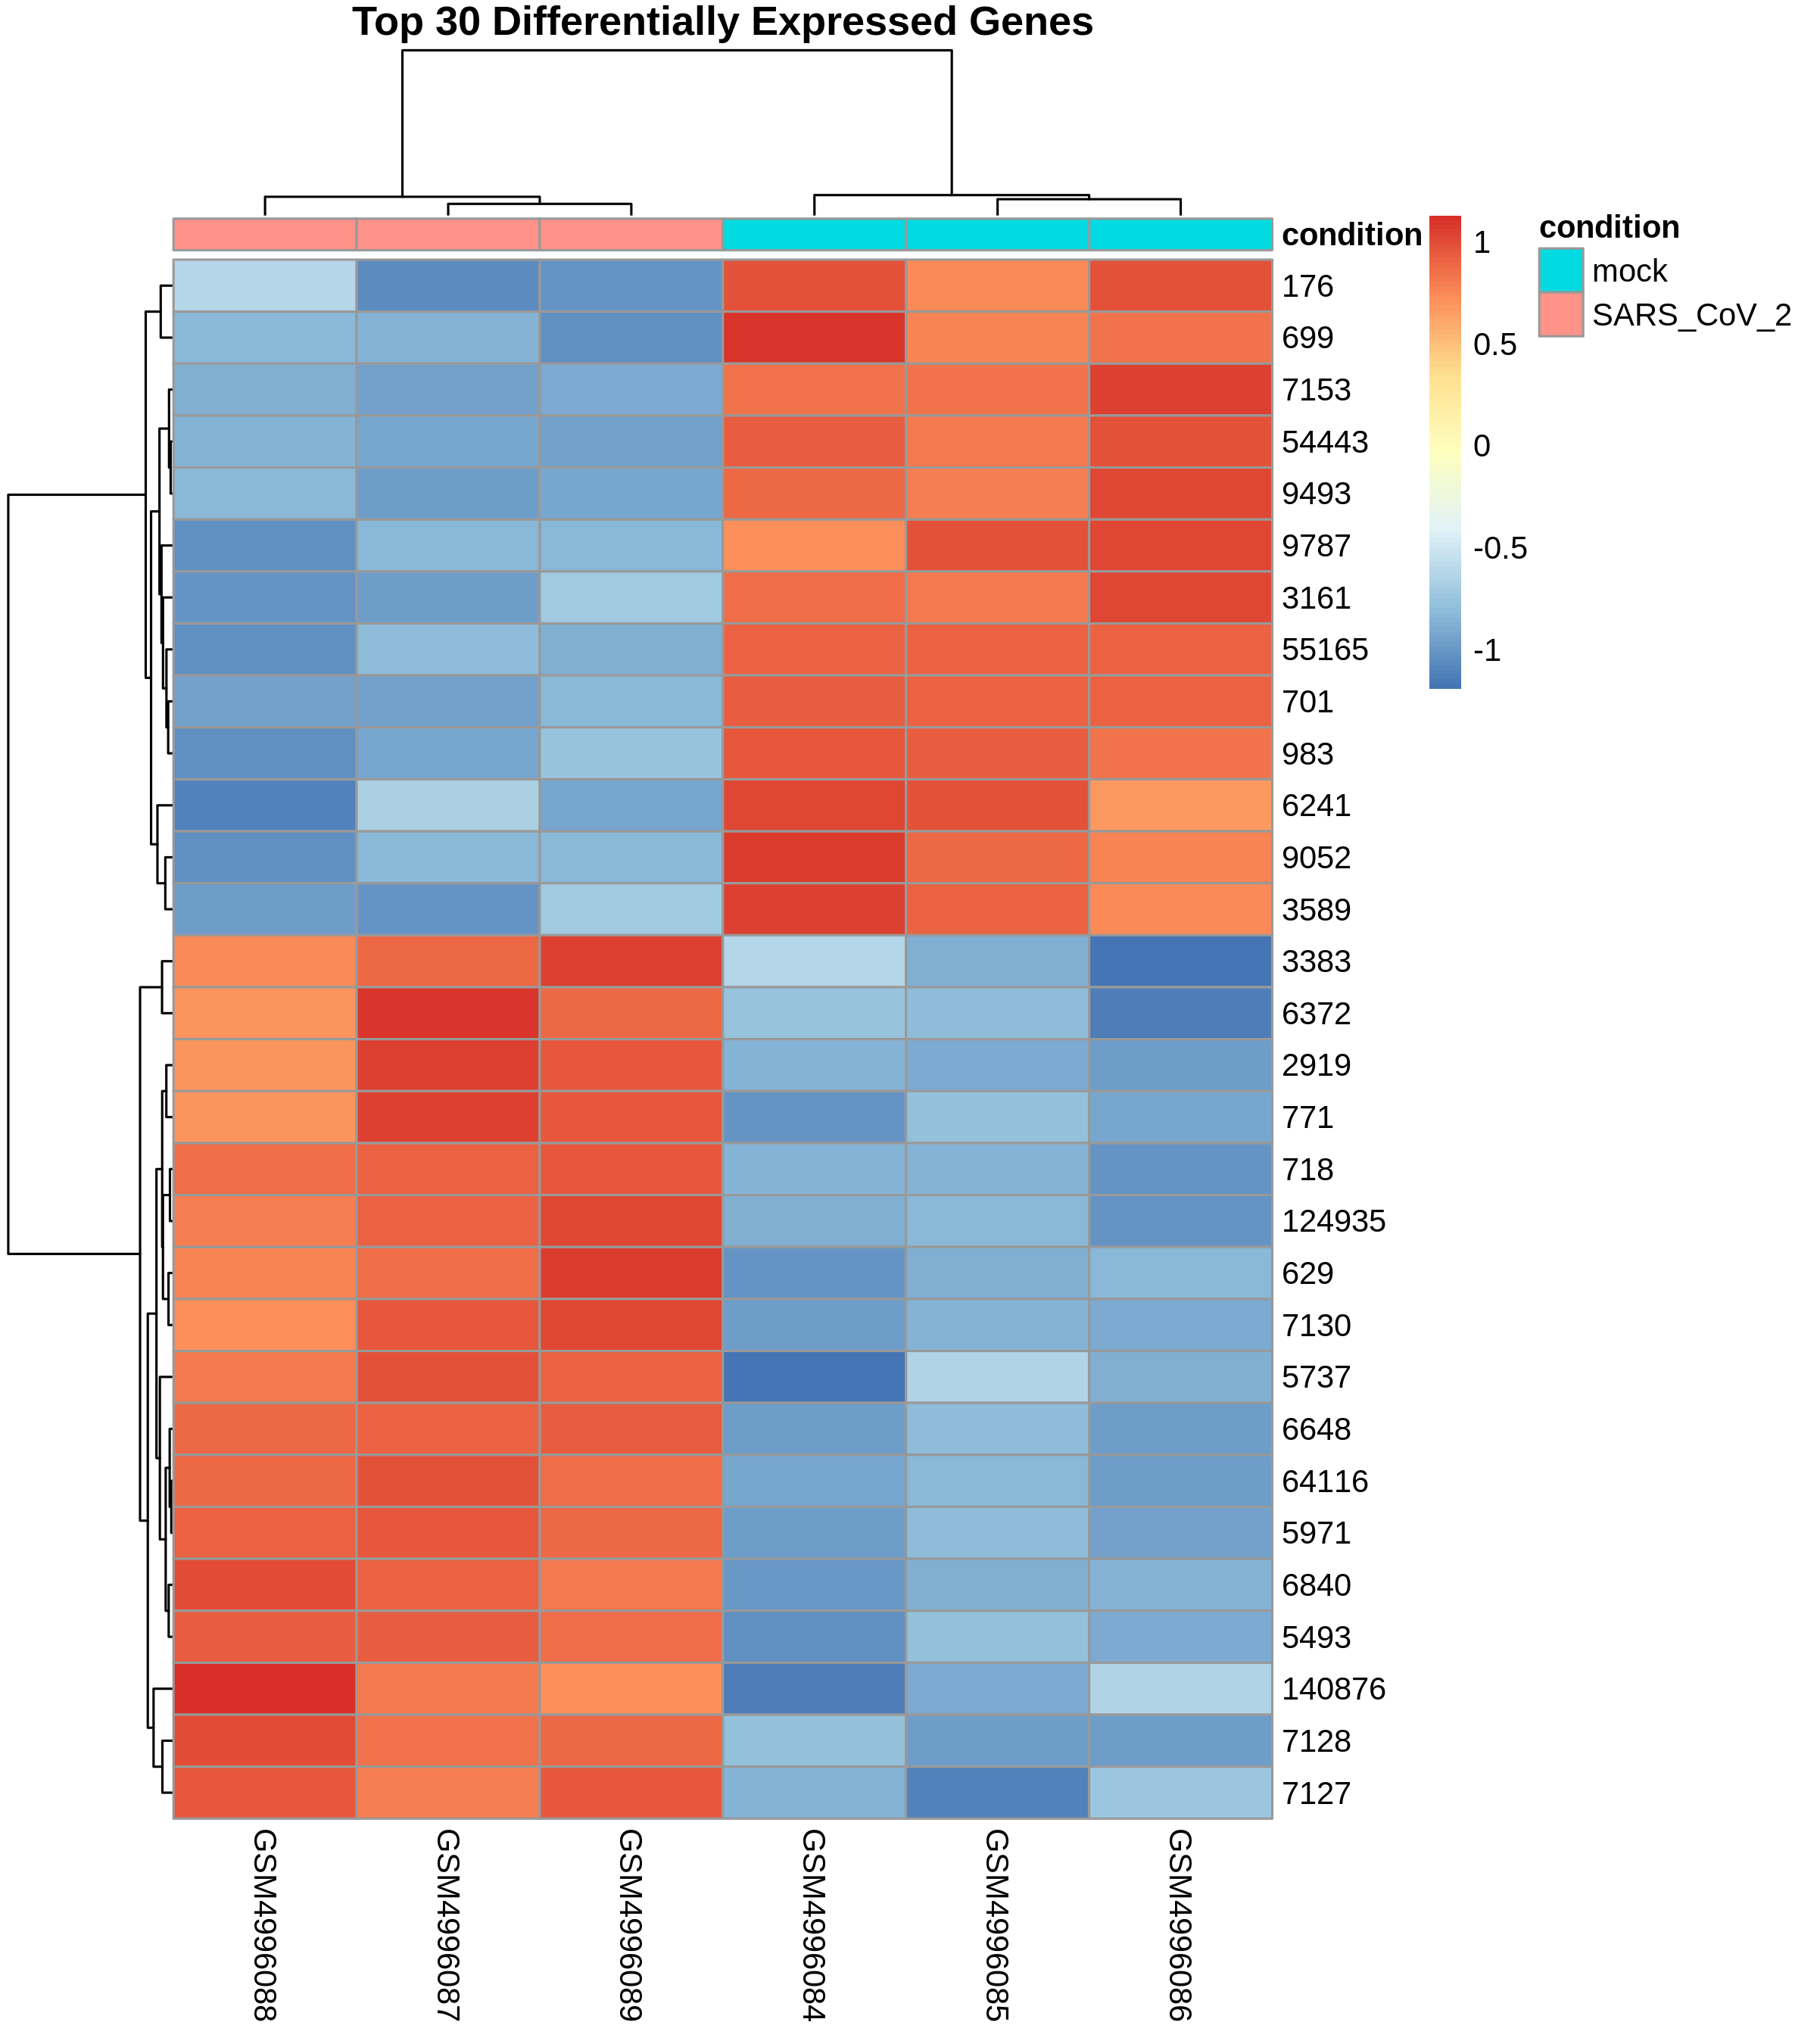

In [190]:
from IPython.display import Image, display
import os

print("Exists:", os.path.exists("plots/top_30_gene_heatmap.png"))
print("Size:", os.path.getsize("plots/top_30_gene_heatmap.png"), "bytes")

display(Image("plots/top_30_gene_heatmap.png"))


In [191]:
from google.colab import files

files.download("results/DESeq2_all_results.csv")
files.download("results/DESeq2_significant_genes.csv")
files.download("results/DESeq2_upregulated_genes.csv")
files.download("results/DESeq2_downregulated_genes.csv")

files.download("plots/MA_plot.png")
files.download("plots/volcano_plot.png")
files.download("plots/PCA_plot.png")
files.download("plots/top_30_gene_heatmap.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [192]:
!mkdir -p scripts results plots logs


In [193]:
!cat logs/deseq2_geo_analysis.log


Setting options('download.file.method.GEOquery'='auto')
Setting options('GEOquery.inmemory.gpl'=FALSE)
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Attaching package: ‘

In [194]:
%%writefile scripts/deseq2_geo_analysis.R
install_if_missing <- function(pkg, bioc = FALSE) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    if (bioc) {
      if (!requireNamespace("BiocManager", quietly = TRUE)) {
        install.packages("BiocManager", repos = "https://cloud.r-project.org")
      }
      BiocManager::install(pkg, ask = FALSE, update = FALSE)
    } else {
      install.packages(pkg, repos = "https://cloud.r-project.org")
    }
  }
}

cran_packages <- c("ggplot2", "dplyr", "readr", "tibble")
bioc_packages <- c("DESeq2", "GEOquery", "SummarizedExperiment", "apeglm", "EnhancedVolcano", "pheatmap")

for (pkg in cran_packages) install_if_missing(pkg, bioc = FALSE)
for (pkg in bioc_packages) install_if_missing(pkg, bioc = TRUE)

library(DESeq2)
library(GEOquery)
library(SummarizedExperiment)
library(apeglm)
library(EnhancedVolcano)
library(pheatmap)
library(ggplot2)
library(dplyr)
library(readr)
library(tibble)

dir.create("results", showWarnings = FALSE, recursive = TRUE)
dir.create("plots", showWarnings = FALSE, recursive = TRUE)
dir.create("logs", showWarnings = FALSE, recursive = TRUE)

geo_accession <- "GSE164073"

message("Downloading GEO RNA-seq data...")
se <- getRNASeqData(geo_accession)

sample_info <- as.data.frame(colData(se)) %>%
  dplyr::mutate(
    tissue = dplyr::case_when(
      grepl("Cornea", title, ignore.case = TRUE) ~ "cornea",
      grepl("Limbus", title, ignore.case = TRUE) ~ "limbus",
      grepl("Sclera", title, ignore.case = TRUE) ~ "sclera",
      TRUE ~ NA_character_
    ),
    condition = dplyr::case_when(
      grepl("mock", title, ignore.case = TRUE) ~ "mock",
      grepl("CoV2", title, ignore.case = TRUE) ~ "SARS_CoV_2",
      TRUE ~ NA_character_
    )
  )

cornea_samples <- sample_info %>%
  dplyr::filter(tissue == "cornea") %>%
  dplyr::pull(geo_accession)

count_data <- assay(se, "counts")[, cornea_samples]

metadata <- sample_info %>%
  dplyr::filter(geo_accession %in% cornea_samples) %>%
  dplyr::select(geo_accession, title, tissue, condition)

rownames(metadata) <- metadata$geo_accession
metadata <- metadata[colnames(count_data), ]
metadata$condition <- factor(metadata$condition)

if (!all(colnames(count_data) == rownames(metadata))) {
  stop("Sample names in count matrix and metadata do not match.")
}

readr::write_csv(
  metadata %>% tibble::rownames_to_column("sample_id"),
  "results/sample_metadata.csv"
)

dds <- DESeqDataSetFromMatrix(
  countData = count_data,
  colData = metadata,
  design = ~ condition
)

dds <- dds[rowSums(counts(dds)) >= 10, ]
dds$condition <- relevel(dds$condition, ref = "mock")

message("Running DESeq2...")
dds <- DESeq(dds)

res <- results(
  dds,
  contrast = c("condition", "SARS_CoV_2", "mock")
)

res_ordered <- res[order(res$padj), ]

res_df <- as.data.frame(res_ordered) %>%
  tibble::rownames_to_column(var = "GeneID") %>%
  dplyr::filter(!is.na(padj))

res_df$GeneID <- as.character(res_df$GeneID)

message("Preparing gene annotation...")

gene_annotation_raw <- as.data.frame(rowData(se))

if ("GeneID" %in% colnames(gene_annotation_raw)) {
  gene_annotation_raw$GeneID <- as.character(gene_annotation_raw$GeneID)
} else {
  gene_annotation_raw$GeneID <- as.character(rownames(gene_annotation_raw))
}

if ("Symbol" %in% colnames(gene_annotation_raw)) {
  gene_annotation_raw$Symbol_clean <- as.character(gene_annotation_raw$Symbol)
} else {
  gene_annotation_raw$Symbol_clean <- gene_annotation_raw$GeneID
}

if ("Description" %in% colnames(gene_annotation_raw)) {
  gene_annotation_raw$Description_clean <- as.character(gene_annotation_raw$Description)
} else {
  gene_annotation_raw$Description_clean <- NA_character_
}

gene_annotation <- gene_annotation_raw %>%
  dplyr::select(
    GeneID,
    Symbol = Symbol_clean,
    Description = Description_clean
  ) %>%
  dplyr::distinct(GeneID, .keep_all = TRUE)

res_annotated <- res_df %>%
  dplyr::left_join(gene_annotation, by = "GeneID") %>%
  dplyr::relocate(Symbol, Description, .after = GeneID)

significant_genes <- res_annotated %>%
  dplyr::filter(padj < 0.05, abs(log2FoldChange) >= 1)

upregulated_genes <- significant_genes %>%
  dplyr::filter(log2FoldChange > 0)

downregulated_genes <- significant_genes %>%
  dplyr::filter(log2FoldChange < 0)

readr::write_csv(res_annotated, "results/DESeq2_all_results.csv")
readr::write_csv(significant_genes, "results/DESeq2_significant_genes.csv")
readr::write_csv(upregulated_genes, "results/DESeq2_upregulated_genes.csv")
readr::write_csv(downregulated_genes, "results/DESeq2_downregulated_genes.csv")

summary_table <- tibble::tibble(
  comparison = "SARS-CoV-2 vs mock in cornea",
  total_tested_genes = nrow(res_annotated),
  significant_genes = nrow(significant_genes),
  upregulated_genes = nrow(upregulated_genes),
  downregulated_genes = nrow(downregulated_genes)
)

readr::write_csv(summary_table, "results/summary_table.csv")

message("Creating MA plot...")
png("plots/MA_plot.png", width = 900, height = 700)
plotMA(res, ylim = c(-8, 8), main = "MA Plot: SARS-CoV-2 vs Mock in Cornea")
dev.off()

message("Shrinking log2 fold changes...")
res_shrunken <- lfcShrink(
  dds,
  coef = "condition_SARS_CoV_2_vs_mock",
  type = "apeglm"
)

res_shrunken_df <- as.data.frame(res_shrunken) %>%
  tibble::rownames_to_column(var = "GeneID") %>%
  dplyr::filter(!is.na(padj))

res_shrunken_df$GeneID <- as.character(res_shrunken_df$GeneID)

res_shrunken_df <- res_shrunken_df %>%
  dplyr::left_join(gene_annotation, by = "GeneID") %>%
  dplyr::relocate(Symbol, Description, .after = GeneID)

readr::write_csv(res_shrunken_df, "results/DESeq2_shrunken_results.csv")

message("Creating volcano plot...")
res_shrunken_df$plot_label <- ifelse(
  is.na(res_shrunken_df$Symbol) | res_shrunken_df$Symbol == "",
  res_shrunken_df$GeneID,
  res_shrunken_df$Symbol
)

volcano_plot <- EnhancedVolcano(
  res_shrunken_df,
  lab = res_shrunken_df$plot_label,
  x = "log2FoldChange",
  y = "padj",
  title = "SARS-CoV-2 vs Mock in Cornea",
  subtitle = "DESeq2 differential expression",
  xlab = "Log2 fold change",
  ylab = "-log10 adjusted p-value",
  pCutoff = 0.05,
  FCcutoff = 1,
  pointSize = 2,
  labSize = 3,
  drawConnectors = TRUE,
  widthConnectors = 0.5
)

ggplot2::ggsave(
  filename = "plots/volcano_plot.png",
  plot = volcano_plot,
  width = 8,
  height = 7,
  dpi = 300
)

message("Creating PCA plot...")
vsd <- vst(dds, blind = FALSE)

pca_plot <- plotPCA(vsd, intgroup = "condition") +
  ggtitle("PCA Plot: Cornea RNA-seq Samples")

ggplot2::ggsave(
  filename = "plots/PCA_plot.png",
  plot = pca_plot,
  width = 7,
  height = 5,
  dpi = 300
)

message("Creating heatmap...")
top_genes <- res_shrunken_df %>%
  dplyr::filter(!is.na(padj)) %>%
  dplyr::arrange(padj) %>%
  dplyr::slice(1:30) %>%
  dplyr::pull(GeneID)

top_gene_matrix <- assay(vsd)[top_genes, ]
top_gene_matrix_scaled <- t(scale(t(top_gene_matrix)))

annotation_col <- as.data.frame(colData(dds)[, "condition", drop = FALSE])

pheatmap::pheatmap(
  top_gene_matrix_scaled,
  annotation_col = annotation_col,
  show_rownames = TRUE,
  show_colnames = TRUE,
  main = "Top 30 Differentially Expressed Genes",
  filename = "plots/top_30_gene_heatmap.png",
  width = 8,
  height = 9
)

saveRDS(dds, "results/deseq2_dataset.rds")

message("Analysis complete.")


Overwriting scripts/deseq2_geo_analysis.R


In [195]:
%%writefile Snakefile
rule all:
    input:
        "results/DESeq2_all_results.csv",
        "results/DESeq2_significant_genes.csv",
        "results/DESeq2_upregulated_genes.csv",
        "results/DESeq2_downregulated_genes.csv",
        "results/DESeq2_shrunken_results.csv",
        "results/sample_metadata.csv",
        "results/summary_table.csv",
        "plots/MA_plot.png",
        "plots/volcano_plot.png",
        "plots/PCA_plot.png",
        "plots/top_30_gene_heatmap.png"

rule deseq2_geo_analysis:
    output:
        "results/DESeq2_all_results.csv",
        "results/DESeq2_significant_genes.csv",
        "results/DESeq2_upregulated_genes.csv",
        "results/DESeq2_downregulated_genes.csv",
        "results/DESeq2_shrunken_results.csv",
        "results/sample_metadata.csv",
        "results/summary_table.csv",
        "plots/MA_plot.png",
        "plots/volcano_plot.png",
        "plots/PCA_plot.png",
        "plots/top_30_gene_heatmap.png"
    log:
        "logs/deseq2_geo_analysis.log"
    shell:
        "Rscript scripts/deseq2_geo_analysis.R > {log} 2>&1"


Overwriting Snakefile


In [196]:
!snakemake --cores 1 --rerun-incomplete


Assuming unrestricted shared filesystem usage.
host: f5cfdb3b87ad
Building DAG of jobs...
Nothing to be done (all requested files are present and up to date).


In [197]:
!snakemake --cores 1 --forceall


Assuming unrestricted shared filesystem usage.
host: f5cfdb3b87ad
Building DAG of jobs...
Using shell: /usr/bin/bash
Provided cores: 1 (use --cores to define parallelism)
Rules claiming more threads will be scaled down.
Job stats:
job                    count
-------------------  -------
deseq2_geo_analysis        1
all                        1
total                      2

Select jobs to execute...
Execute 1 jobs...

[Sun Apr 19 15:43:55 2026]
localrule deseq2_geo_analysis:
    output: results/DESeq2_all_results.csv, results/DESeq2_significant_genes.csv, results/DESeq2_upregulated_genes.csv, results/DESeq2_downregulated_genes.csv, results/DESeq2_shrunken_results.csv, results/sample_metadata.csv, results/summary_table.csv, plots/MA_plot.png, plots/volcano_plot.png, plots/PCA_plot.png, plots/top_30_gene_heatmap.png
    log: logs/deseq2_geo_analysis.log
    jobid: 1
    reason: Forced execution
    resources: tmpdir=/tmp
[Sun Apr 19 15:44:51 2026]
Finished jobid: 1 (Rule: deseq2_geo_anal

In [198]:
!find results plots -maxdepth 1 -type f


results/DESeq2_shrunken_results.csv
results/sample_metadata.csv
results/deseq2_dataset.rds
results/summary_table.csv
results/DESeq2_significant_genes.csv
results/DESeq2_all_results.csv
results/DESeq2_downregulated_genes.csv
results/DESeq2_upregulated_genes.csv
plots/MA_plot.png
plots/PCA_plot.png
plots/top_30_gene_heatmap.png
plots/volcano_plot.png


In [199]:
!cat logs/deseq2_geo_analysis.log


Setting options('download.file.method.GEOquery'='auto')
Setting options('GEOquery.inmemory.gpl'=FALSE)
Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Attaching package: ‘